In [1]:
# CBM & HM tutorials
# I.M., 2025-2026

# Examples demonstrationg usage of characteristic bisection method (CBM) for fixed points search
# For theoretical framework refer to M. N. Vrahatis, An Efficient Method for Locating and Computing Periodic Orbits of Nonlinear Mappings, 1995
# The CMB main code is a NUBMA friendly adoptation from xsuite/xnlbd by Dora Veres

# The final two examples demonstrate the construction of hyperbolic manifolds in 2D and 4D
# First, the hyperbolic fixed points are located, and initial conditions are seeded within an epsilon-neighborhood spanned by the stable or unstable directions
# These initial conditions are then iterated, and the complete orbits associated with escaping initials are used to construct the transport skeleton and the bounding set

# Adapters

Applying CBM assumes a fixed-point problem formulated via a residual, and the underlying mapping operates on `(n, m)`-shaped arrays (state dimension and number of samples) of initial conditions, whereas elsewhere in the library an `(n, )` input/output shape is assumed. Adapters are provided to convert between `(n, m)` and `(n, )` mappings.

The motivation for using `(n, m)` is to exploit broadcasting and move parallelization to the outer loop (e.g., fixed-point search across many subregions). Many mappings of interest can be adapted to accept and return `(n, m)` arrays with minimal changes. The remainder of this example illustrates how to convert an existing `(n, )` mapping to `(n, m)`, and how adapters can automatically construct the required variants. Note, however, that the automatic construction does not use broadcasting; it relies on looping over initial conditions (optionally parallelized across threads).

Consider the following `(n, )` symplectic mapping:

In [1]:
import numpy as np
from numpy.typing import NDArray
from numba import njit

@njit
def scalar(
    x: NDArray[np.float64], 
    parameters: NDArray[np.float64]
) ->  NDArray[np.float64]:
    q, p = x
    a, b = parameters
    Q = p
    P = -q + a*p + b*p**2 
    return np.array([Q, P])

And the correspoinding mapping invocation for given `(n, )` initial condition:

In [2]:
x = np.array([0.1, -0.1])
parameters = np.array([0.47, 1.0])
scalar(x, parameters)

array([-0.1  , -0.137])

It can be converted to a mapping acting on `(n, m)` arrays with a single line change:

In [3]:
@njit
def vector(
    x: NDArray[np.float64], 
    parameters: NDArray[np.float64]
) ->  NDArray[np.float64]:
    q, p = x
    a, b = parameters
    Q = p
    P = -q + a*p + b*p**2 
    return np.stack((Q, P))

And now it acts and returns arrays with `(n, m)` shape:

In [4]:
xs = np.array([[0.1], [-0.1]])
parameters = np.array([0.47, 1.0])
vector(xs, parameters)

array([[-0.1  ],
       [-0.137]])

In the above, broadcasting is used to perform elementwise operations like `+` which is done using vectorized CPU instructions.

The `scalarize` adapter can be used to make `vector` behave like `scalar`:

In [5]:
from domain.adapters import scalarize

scalarize(vector)(x, parameters)

array([-0.1  , -0.137])

The `vectorize` adapter can be used to make `scaler` behave like `vector`:

In [6]:
from domain.adapters import vectorize

vectorize(scalar)(xs, parameters)

array([[-0.1  ],
       [-0.137]])

Note, however that this doesn't exploit broadcastion, but only (parallel) loops over initials.

Given a `(n, )` mapping we can use `vectorize` to define single-threaded and multi-threaded versions.

In [7]:
foo = vectorize(scalar, parallel=False)
foo(xs, parameters)

array([[-0.1  ],
       [-0.137]])

In [8]:
bar = vectorize(scalar, parallel=True)
bar(xs, parameters)

array([[-0.1  ],
       [-0.137]])

Up to some point (input size) broadcasting is expected to out perform parallezation over threads:

In [9]:
xs = np.random.randn(len(x), int(1E+4))

%timeit vector(xs, parameters)
%timeit foo(xs, parameters)
%timeit bar(xs, parameters)

17 μs ± 309 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
791 μs ± 25.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
347 μs ± 15.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


For large inputs parallezation over theads is expected to catch up:

In [10]:
xs = np.random.randn(len(x), int(1E+8))

%timeit vector(xs, parameters)
%timeit foo(xs, parameters)
%timeit bar(xs, parameters)

1.1 s ± 95 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
10 s ± 1.02 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
736 ms ± 68.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Note, it is also possible to batch the input and exploit both broadcasting and threads utilization.

# Fixed point problem setup

CBM fixed point search functions require fixed point problem as input (callable returning residual).
Given a `(n, m)` mapping $\mathcal{M}$:

In [1]:
import numpy as np
from numpy.typing import NDArray
from numba import njit

@njit
def mapping(
    x: NDArray[np.float64], 
    parameters: NDArray[np.float64]
) ->  NDArray[np.float64]:
    q, p = x
    a, b = parameters
    Q = p
    P = -q + a*p + b*p**2 
    return np.stack((Q, P))

The fixed point problem is to solve $\mathcal{M}^{p}(x^{*}) - x^{*} = 0$ system of algebraic equations for $x^*$ - an order-p periodic fixed point.

Given $\mathcal{M}$, $p$ applications of $\mathcal{M}$ on some initial state can be computed using `trajectory` function:

In [2]:
from domain.fp import trajectory

qs = np.linspace(0.0, 1.0, 64)
ps = np.linspace(0.0, 1.0, 64)
xs = np.stack([qs, ps])

parameters = np.array([0.5, 1.0])

table = trajectory(2**12, mapping, xs, parameters)
table.shape

(4096, 2, 64)

This function can also be used to compute phase space trajectories:

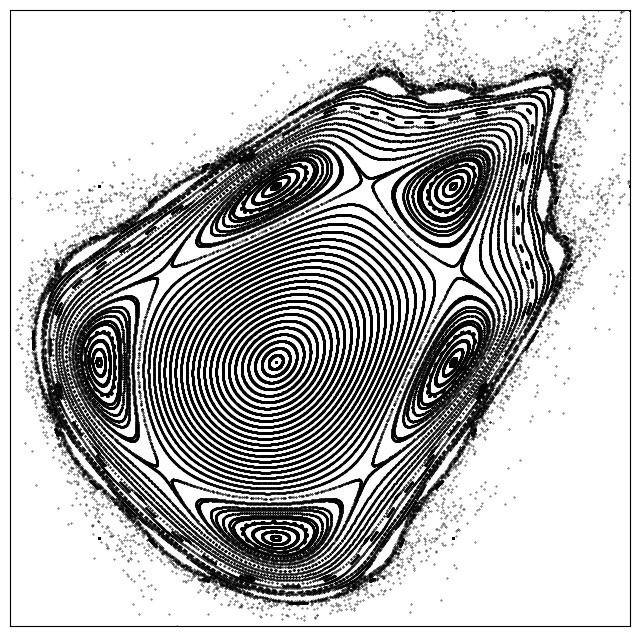

In [3]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-0.75, 1.00)
plt.ylim(-0.75, 1.00)
plt.show()

Provided `problem` factory can be used to construct fixed point problem (residual) from the given mapping:

In [4]:
from domain.fp import problem

order = 5
residual = problem(mapping, order=order)

The constructed function has the same invocation signature as the initial mapping:

In [5]:
np.allclose(residual(xs, parameters), trajectory(order, mapping, xs, parameters, orbit=False).squeeze() - xs)

True

Note, `trajectory` with `orbit=False` returns onle the final iteration with shape `(1, n, m)`.

Since for this mapping origin is a period one fixed point, the residual is equal to zero for any order:

In [6]:
xs = np.array([[0.0], [0.0]])
residual(xs, parameters)

array([[0.],
       [0.]])

Residual is also expected to be small near the fixed point:

In [7]:
epsilon = 1.0E-3
residual(xs + epsilon, parameters)

array([[ 0.00018723],
       [-0.00028091]])

Given known roots, it is possible to construct a fixed point problem with roots deflation:

In [8]:
roots = np.array([[0.0, 0.0]])
powers = np.array([1])

residual = problem(mapping, order=order, roots=roots, powers=powers)

The residual will still be zero at exact roots:

In [9]:
residual(xs, parameters)

array([[0.],
       [0.]])

But will increase near the roots:

In [10]:
residual(xs + epsilon, parameters)

array([[ 0.13239442],
       [-0.19863242]])

Since CBM method relies on evaluation of signs, roots deflation is not expected to 'mask' known roots.

The final utils function `expand` can be used to add order as the last element of `parameters` array.
This might be desirable since in this case order change will not result in recompilation of numba kernels.

In [11]:
xs = np.array([[0.01], [0.01]])
parameters = np.array([0.5, 1.0])

In [12]:
residual = problem(mapping, order=order)
residual(xs, parameters)

array([[ 0.00184804],
       [-0.00277702]])

In [14]:
from domain.fp import expand

residual = problem(expand(mapping), order=1)
parameters = np.array([0.5, 1.0, order])
residual(xs, parameters)

array([[ 0.00184804],
       [-0.00277702]])

# 2D Henon mapping fixed points

In this example `solve` function is used to locate periodic fixed points of 2D symplectic Henon mapping using characteristic bisection method. This function implements CBM fixed point search method (construction of initial characteristic polyhydron and its generalized bisection). The construction of initial characteristic polyhydron involves random sampling and the number of random samples required is approximatly $10^n$ with $n$ being the problem dimension.

First, setup test `(n, m)` 2D symplectic Henon mapping and plot phase space trajectories along the diagonal symmetry line.
There is an elliptic fixed point at the origin and several chains, e.g. period five.

In [1]:
import numpy as np

from domain.mappings import forward2D as mapping
from domain.fp import trajectory

qs = np.linspace(0.0, 1.0, 64)
ps = np.linspace(0.0, 1.0, 64)
xs = np.stack([qs, ps])

parameters = np.array([0.5, 0.0])

table = trajectory(2**12, mapping, xs, parameters)
table.shape

(4096, 2, 64)

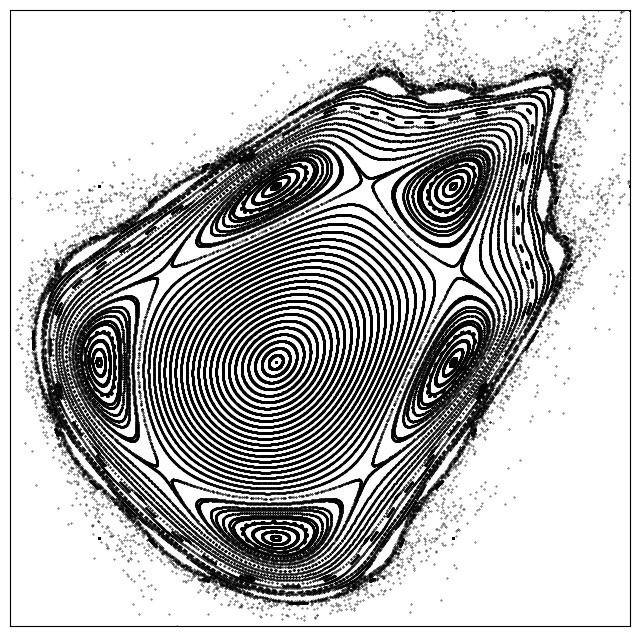

In [2]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-0.75, 1.00)
plt.ylim(-0.75, 1.00)
plt.show()

Define the fixed point problem for period five:

In [3]:
from domain.fp import problem

order = 5
residual = problem(mapping, order=order)

Given a search region defined by bounds, fixed points can be located using `solve` function.
Apart from the fixed problem, it requires indices of polygon edges as input for given dimension:

In [4]:
from domain.cbm import edges

n = 2
es = edges(n)
es

array([[1, 3],
       [1, 2],
       [2, 4],
       [3, 4]])

In [5]:
from domain.cbm import solve

bs = np.array([[-1.0, 1.0], [-1.0, 1.0]])

solve(
    es,                   # -- hypercube edge indices
    bs,                   # -- [..., [min, max], ...] bounds for each dimension
    residual,             # -- fixed point function
    parameters,           # -- additional function parameters
    tolerance=1.0E-12,    # -- fixed point estimation target tolerance
    ncube=16,             # -- number of grid points per dimension
    nball=256,            # -- number of sphere random points
    max_iterations=64,    # -- maximum number of generalised-bisection steps
    max_expansions=32     # -- maximum number of sphere-radius expansions (initial polyhedron construction)
)

(True, array([ 1.02558277e-12, -2.12249802e-12]), 33)

With parameters given, the above result of `solve` will most likely converge to an elliptical fixed point at the origin or it might fail with some low probability.
The `(False, array([nan, nan]), 0)` output indicates a failure constructing initial proper polygon.
It is constructed using random sampling and might fail if the `nball` value is small.
Note, $10^n$ is a good default for this parameter. 
Another failure is indicated by the `(False, array([nan, nan]), 64)` output.
In this case convergence was not reached with `64` bisection operations.

In [6]:
solve(es, bs, residual, parameters,  tolerance=1.0E-12, ncube=16, nball=8, max_iterations=64, max_expansions=32)

(False, array([nan, nan]), 0)

In [7]:
solve(es, bs, residual, parameters,  tolerance=1.0E-12, ncube=16, nball=256, max_iterations=8, max_expansions=32)

(False, array([nan, nan]), 8)

Note, on the first run `solve` will be jit-compiled and its subsequent invoations are much faster.

Since out goal is to locage period five fixed points, several options are avalible:

- Adjust the initial region defined by the bounds (e.g. based on observed phase space trajectories)
- Define a fixed problem with known roots to avoid (non-recomended, since CBM uses signs)
- Sptil the initial region into small tiles and perform search for each one and filter the results (see the next example)

Specify a more targeted search region:

In [8]:
bs = np.array([[0.3, 0.7], [0.3, 0.7]])
check, point, count = solve(es, bs, residual, parameters,  tolerance=1.0E-12, ncube=16, nball=256, max_iterations=64, max_expansions=32)
check, point, count

(True, array([0.5, 0.5]), 31)

Compute the full chain and plot the fixed point location:

In [9]:
chain = trajectory(order, mapping, point.reshape(-1, 1), parameters)
chain

array([[[ 5.00000000e-01],
        [-1.21841426e-12]],

       [[-1.21841426e-12],
        [-5.00000000e-01]],

       [[-5.00000000e-01],
        [ 1.44623202e-12]],

       [[ 1.44623202e-12],
        [ 5.00000000e-01]],

       [[ 5.00000000e-01],
        [ 5.00000000e-01]]])

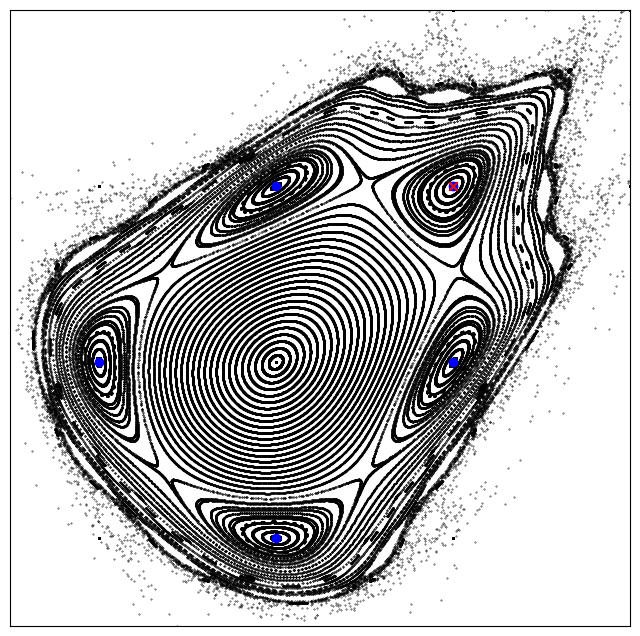

In [10]:
plt.figure(figsize=(8, 8))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1)
plt.scatter(*chain.T.squeeze(), color='blue', marker='o')
plt.scatter(*point, color='red', marker='x')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-0.75, 1.00)
plt.ylim(-0.75, 1.00)
plt.show()

# 2D Henon mapping fixed points: tiling and parallel search 

In this example the region of interest is splitted into subregions and CBM is applied to each subregion using thread parallelization with `psolve` function.
The results for each region are combined and filtered using several utility functions.

First, setup test `(n, m)` 2D symplectic Henon mapping and plot phase space trajectories along the diagonal symmetry line.
There is an elliptic fixed point at the origin and several chains, e.g. period five.

In [11]:
import numpy as np

from domain.mappings import forward2D as mapping
from domain.fp import trajectory

qs = np.linspace(0.0, 1.0, 64)
ps = np.linspace(0.0, 1.0, 64)
xs = np.stack([qs, ps])

parameters = np.array([0.5, 0.0])

table = trajectory(2**12, mapping, xs, parameters)
table.shape

(4096, 2, 64)

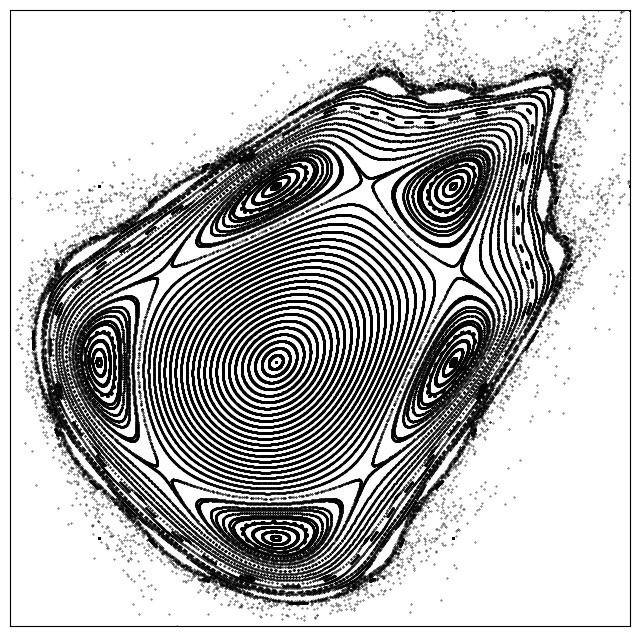

In [12]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-0.75, 1.00)
plt.ylim(-0.75, 1.00)
plt.show()

Define a fixed point problem for period five:

In [13]:
from domain.fp import problem

order = 5
residual = problem(mapping, order=order)

Compute edge indices:

In [14]:
from domain.cbm import edges

n = 2
es = edges(n)
es

array([[1, 3],
       [1, 2],
       [2, 4],
       [3, 4]])

Given a search box, `tiles` can be used to split it into smaller overlapping subregions:

In [15]:
from domain.cbm import tiles

bs = np.array([[-1.0, 1.0], [-1.0, 1.0]])

ns = np.array([64, 64])
ts = tiles(bs, ns, overlap=0.1)
ts.shape

(4096, 2, 2)

Next, `psolve` can be used to perform fixed point search for given tiles:

In [16]:
from domain.cbm import psolve

checks, points, counts = psolve(
    es,                   # -- hypercube edge indices
    ts,                   # -- tiles
    residual,             # -- fixed point function
    parameters,           # -- additional function parameters
    tolerance=1.0E-12,    # -- fixed point estimation target tolerance
    ncube=16,             # -- number of grid points per dimension
    nball=256,            # -- number of sphere random points
    max_iterations=64,    # -- maximum number of generalised-bisection steps
    max_expansions=32     # -- maximum number of sphere-radius expansions (initial polyhedron construction)
)

The above returns:
- `checks` - array 0/1 for failed/succesfull search
- `points` - array of fixed points, with NaNs for failed (polygon construction or convergence failures)
- `counts` - array of number of iterations (points with max number of iterations are set to NaNs)

Failed cases can be filtered out by a mask (or just remove NaNs):

In [17]:
data = points[(checks == 1) & (counts != 256)]

`data` will contain duplicates and non-exact periodic points, e.g. period one fixed point is also a period five fixed point:

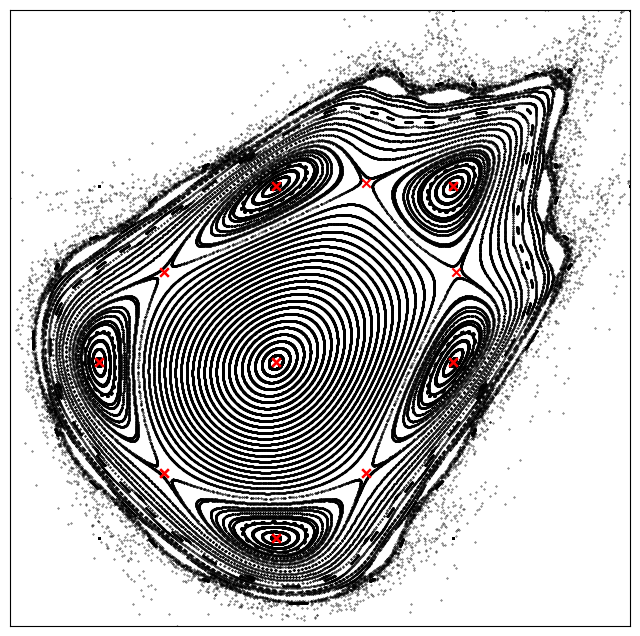

In [18]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1)
plt.scatter(*data.swapaxes(0, 1), color='red', marker='x')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-0.75, 1.00)
plt.ylim(-0.75, 1.00)
plt.show()

Several utility fuctions are avaliable to filter periodic points.
`exact` counts the number of times the fixed point returns to itself (given some numerical tolerance).
If this number is equal to one, then the points are considered to be exact.

In [19]:
from domain.fp import exact

data = points[(checks == 1) & (counts != 256)]
data = data[exact(order, mapping, data, parameters, tolerance=1.0E-6)]

This removes period one fixed point:

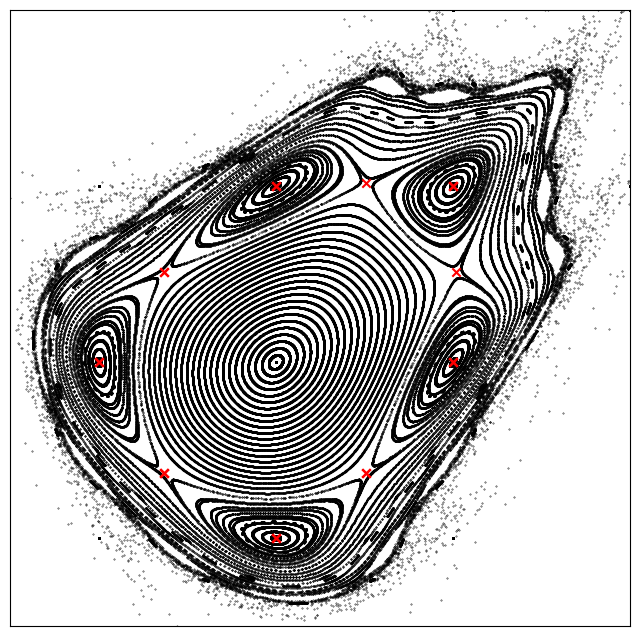

In [20]:
plt.figure(figsize=(8, 8))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1)
plt.scatter(*data.swapaxes(0, 1), color='red', marker='x')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-0.75, 1.00)
plt.ylim(-0.75, 1.00)
plt.show()

`unique` perfoms lex-sorting of chains generated by exact points and returs unique ones:

In [23]:
from domain.fp import unique

data = points[(checks == 1) & (counts != 256)]
data = data[exact(order, mapping, data, parameters, tolerance=1.0E-6)]
data = data[unique(order, mapping, data, parameters, tolerance=1.0E-6)]

Compute chains using unique fixed points:

In [24]:
chains = trajectory(order, mapping, data.T, parameters)

Plot unique fixed points and corresponding chains:

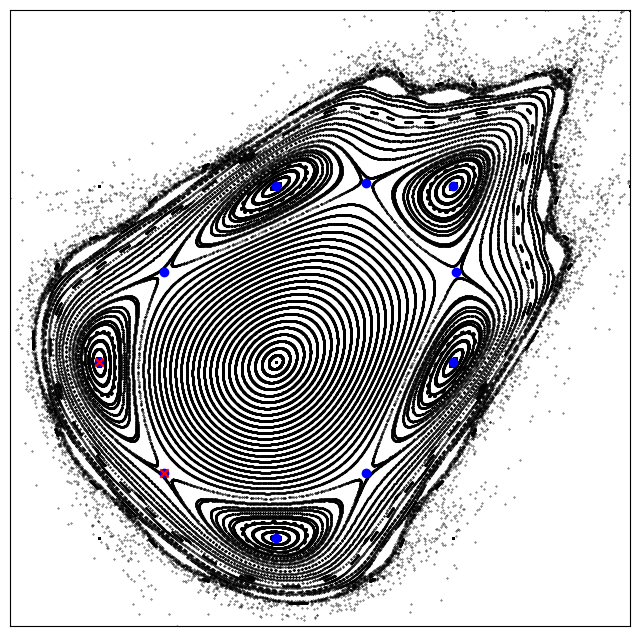

In [25]:
plt.figure(figsize=(8, 8))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1)
plt.scatter(*chains.swapaxes(0, 1), color='blue', marker='o')
plt.scatter(*data.swapaxes(0, 1), color='red', marker='x')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-0.75, 1.00)
plt.ylim(-0.75, 1.00)
plt.show()

Similary, we can target higher order fixed points (note, redefinition of `residual` triggers re-compilation, use `extend` to include `order` as a parameter):

In [26]:
order = 16
residual = problem(mapping, order=order)

In [27]:
bs = np.array([[-1.0, 1.0], [-1.0, 1.0]])
ns = np.array([64, 64])
ts = tiles(bs, ns, overlap=0.1)

In [28]:
checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-9, ncube=16, nball=256, max_iterations=256, max_expansions=64)

In [29]:
data = points[(checks == 1) & (counts != 256)]
data = data[exact(order, mapping, data, parameters, tolerance=1.0E-6)]
data = data[unique(order, mapping, data, parameters, tolerance=1.0E-6)]

In [30]:
chains = trajectory(order, mapping, data.T, parameters)

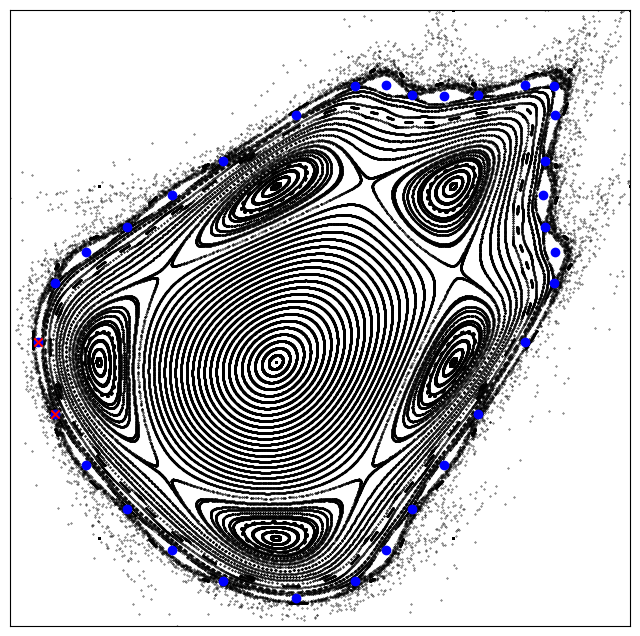

In [31]:
plt.figure(figsize=(8, 8))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1)
plt.scatter(*chains.swapaxes(0, 1), color='blue', marker='o')
plt.scatter(*data.swapaxes(0, 1), color='red', marker='x')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-0.75, 1.00)
plt.ylim(-0.75, 1.00)
plt.show()

# 4D Henon mapping fixed points

In this example, CBM fixed point search is illustrated for 4D Hennon mapping.
The main difference wiht 2D is that the number of random samples for initial characteristic polygon construction should be increased, since default values are somewhat  taylored for 2D case.

Import test mapping and CBM related functions:

In [32]:
import numpy as np

from domain.mappings import forward4D as mapping

from domain.fp import trajectory
from domain.fp import expand
from domain.fp import problem
from domain.fp import exact
from domain.fp import unique

from domain.cbm import edges
from domain.cbm import tiles
from domain.cbm import psolve

Set mapping parameters:

In [33]:
nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 0.0
knobs = np.asarray([cx, sx, cy, sy, mu])

Define expanded problem:

In [34]:
residual = problem(expand(mapping))

Compute edge indices:

In [35]:
n = 4
es = edges(n)
es

array([[ 1,  9],
       [ 1,  5],
       [ 1,  3],
       [ 1,  2],
       [ 2, 10],
       [ 2,  6],
       [ 2,  4],
       [ 3, 11],
       [ 3,  7],
       [ 3,  4],
       [ 4, 12],
       [ 4,  8],
       [ 5, 13],
       [ 5,  7],
       [ 5,  6],
       [ 6, 14],
       [ 6,  8],
       [ 7, 15],
       [ 7,  8],
       [ 8, 16],
       [ 9, 13],
       [ 9, 11],
       [ 9, 10],
       [10, 14],
       [10, 12],
       [11, 15],
       [11, 12],
       [12, 16],
       [13, 15],
       [13, 14],
       [14, 16],
       [15, 16]])

Split search space:

In [36]:
bs = np.array([[-1, 1], [-1, 1], [-1, 1], [-1, 1]])
cs = np.array([5, 5, 5, 5])
ts = tiles(bs, cs, overlap=0.1)
ts.shape

(625, 4, 2)

Search for period-1 fixed points:

In [37]:
%%time

order = 1
parameters = np.stack([*knobs, order])

checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-9, ncube=16, nball=2**10, max_iterations=256, max_expansions=64)
points = points[(checks == 1) & (counts != 256)]
points = points[exact(order, mapping, points, knobs, tolerance=1.0E-9)]
if points.size:
    points = points[unique(order, mapping, points, knobs, tolerance=1.0E-6)]
    chains = trajectory(order, mapping, np.ascontiguousarray(points.T), knobs).swapaxes(0, 1)

print(points)

[[-9.20654298e-11  8.05703160e-10  6.19833143e-10 -2.86864742e-10]]
CPU times: user 24.1 s, sys: 589 ms, total: 24.7 s
Wall time: 20.3 s


Note, first time execution of the above will perform numba jit compilation.
Subsequent invocations will use compiled version.

Next, search for period-5 fixed points:

In [38]:
%%time

order = 5
parameters = np.stack([*knobs, order])

checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-9, ncube=16, nball=2**10, max_iterations=256, max_expansions=64)
points = points[(checks == 1) & (counts != 256)]
points = points[exact(order, mapping, points, knobs, tolerance=1.0E-9)]
if points.size:
    points = points[unique(order, mapping, points, knobs, tolerance=1.0E-6)]
    chains = trajectory(order, mapping, np.ascontiguousarray(points.T), knobs).swapaxes(0, 1)

print(points)

[[ 0.10033137 -0.6373762   0.54186547  0.07477984]
 [ 0.10033137 -0.6373762  -0.14568344 -0.2026775 ]
 [ 0.24008339 -0.46172741 -0.13995635 -0.63133279]
 [ 0.24008339  0.46172741 -0.13995635  0.63133278]]
CPU times: user 20.8 s, sys: 37.8 ms, total: 20.8 s
Wall time: 1.71 s


Search for period-2 fixed points (expected to be empty) :

In [39]:
%%time

order = 2
parameters = np.stack([*knobs, order])

checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-9, ncube=16, nball=2**10, max_iterations=256, max_expansions=64)
points = points[(checks == 1) & (counts != 256)]
points = points[exact(order, mapping, points, knobs, tolerance=1.0E-9)]
if points.size:
    points = points[unique(order, mapping, points, knobs, tolerance=1.0E-6)]
    chains = trajectory(order, mapping, np.ascontiguousarray(points.T), knobs).swapaxes(0, 1)

print(points)

[]
CPU times: user 5.27 s, sys: 6.14 ms, total: 5.27 s
Wall time: 634 ms


# 2D Henon: parametric fixed points

In this example periodic fixed points on Henon sets defined by its symmetry lines are computed as a function of the mapping parameter.

Import:

In [40]:
from typing import Callable

import numpy as np
from numpy.typing import NDArray

from numba import njit
from numba import prange

from domain.fp import trajectory
from domain.fp import expand
from domain.fp import problem
from domain.fp import exact
from domain.fp import unique

from domain.cbm import edges
from domain.cbm import tiles
from domain.cbm import psolve

from tqdm import tqdm

from matplotlib import pyplot as plt

Define test mapping and symmetry lines:

In [41]:
@njit
def mapping(
    x: NDArray[np.float64], 
    parameters: np.float64
) ->  NDArray[np.float64]:
    q, p = x
    a, b = parameters
    Q = p
    P = -q + a*p + b*p**2 
    return np.stack((Q, P))

In [42]:
@njit
def line_a(q, parameters):
    a, b = parameters
    return q

In [43]:
@njit
def line_b(q, parameters):
    a, b = parameters
    return 0.5*(a*q + b*q**2)

Generate  Henon fractals (survival plots along mapping symmetry lines):

In [44]:
@njit(parallel=True)
def fractal(
    limit: int,
    ks: NDArray[np.float64],
    qs: NDArray[np.float64],
    mapping: Callable[[NDArray[np.float64], np.float64], NDArray[np.float64]],
    line: Callable[[NDArray[np.float64], np.float64], NDArray[np.float64]]
) -> NDArray[np.float64]:
    ps = np.empty(len(qs), dtype=np.float64)
    rs = np.empty((len(ks), len(qs)), dtype=np.float64)
    for i in prange(len(ks)):
        ps = line(qs, ks[i])
        xs = np.stack((qs, ps))
        for _ in range(limit):
            xs = mapping(xs, ks[i])
        _, ps = xs
        rs[i] = np.isnan(ps)
    return rs

In [45]:
n = 2**10
m = 2001

a = np.linspace(-3.0, 2.0, m)
b = np.ones_like(a)
ks = np.ascontiguousarray(np.stack([a, b]).T)
qs = np.linspace(-1.25, 1.75, m)

fractal_a = fractal(n, ks, qs, mapping, line_a)
fractal_b = fractal(n, ks, qs, mapping, line_b)

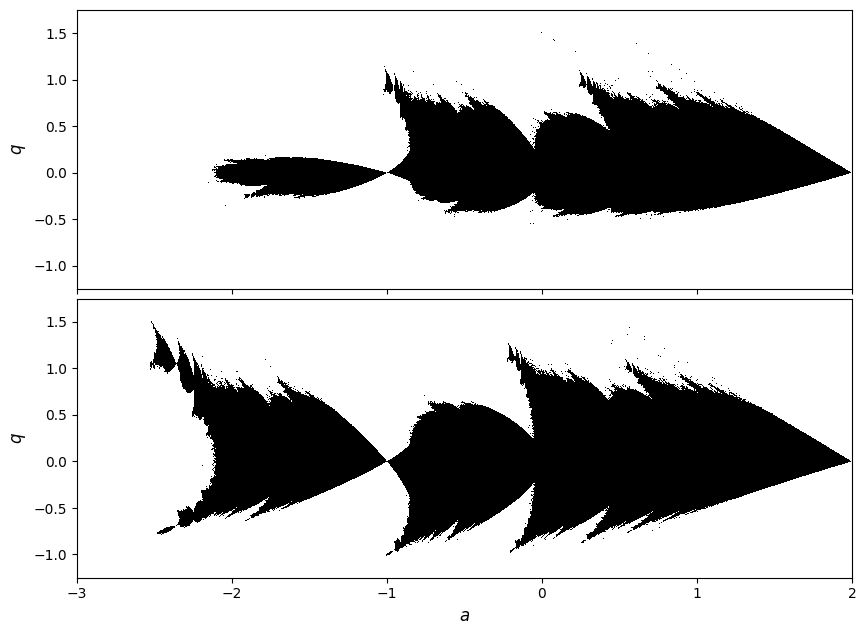

In [46]:
fig, (ax, ay) = plt.subplots( nrows=2, figsize=(10, 10), sharex=True, gridspec_kw={'hspace': -0.4}, num=1, clear=True)
ax.imshow(fractal_a.T, aspect=3/5, origin='lower', interpolation='nearest', cmap='gray', extent=(-3, 2, -1.25, 1.75))
ay.imshow(fractal_b.T, aspect=3/5, origin='lower', interpolation='nearest', cmap='gray', extent=(-3, 2, -1.25, 1.75))
ax.set_ylabel(r'$q$', fontsize=12)
ay.set_ylabel(r'$q$', fontsize=12)  
ay.set_xlabel(r'$a$', fontsize=12)
plt.show()

Define expanded fixed point problem:

In [47]:
residual = problem(expand(mapping))

Set region boundaries, edge indices and tiles:

In [48]:
bs = np.array([[-1.5, 1.5], [-1.5, 1.5]])
es = edges(len(bs))
ns = np.array([32, 32])
ts = tiles(bs, ns, overlap=0.1)
print(ts.shape)

(1024, 2, 2)


Compute fixed points for different orders:

In [49]:
order = 1

box_a_01 = []
box_b_01 = []

for k in tqdm(ks):
    a, b = k
    parameters = np.stack([*k, order])
    checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-12, ncube=32, nball=512, max_iterations=512, max_expansions=64)
    points = points[(checks == 1) & (counts != 512)]
    points = points[exact(order, mapping, points, k, tolerance=1.0E-9)]
    if points.size == 0:
        continue
    points = points[unique(order, mapping, points, k, tolerance=1.0E-6)]           
    points = trajectory(order, mapping, np.ascontiguousarray(points.T), k).T.reshape(-1, 2)
    qs, ps = points.T
    ma = np.abs(ps - line_a(qs, k)) < 1.0E-6
    mb = np.abs(ps - line_b(qs, k)) < 1.0E-6
    vs = np.stack([np.full_like(qs, a), qs]).T
    box_a_01.append(vs[ma])
    box_b_01.append(vs[mb])    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2001/2001 [00:28<00:00, 69.65it/s]


In [50]:
order = 2

box_a_02 = []
box_b_02 = []

for k in tqdm(ks):
    a, b = k
    parameters = np.stack([*k, order])
    checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-12, ncube=32, nball=512, max_iterations=512, max_expansions=64)
    points = points[(checks == 1) & (counts != 512)]
    points = points[exact(order, mapping, points, k, tolerance=1.0E-9)]
    if points.size == 0:
        continue
    points = points[unique(order, mapping, points, k, tolerance=1.0E-6)]           
    points = trajectory(order, mapping, np.ascontiguousarray(points.T), k).T.reshape(-1, 2)
    qs, ps = points.T
    ma = np.abs(ps - line_a(qs, k)) < 1.0E-6
    mb = np.abs(ps - line_b(qs, k)) < 1.0E-6
    vs = np.stack([np.full_like(qs, a), qs]).T
    box_a_02.append(vs[ma])
    box_b_02.append(vs[mb])    

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2001/2001 [00:12<00:00, 165.38it/s]


In [51]:
order = 3

box_a_03 = []
box_b_03 = []

for k in tqdm(ks):
    a, b = k
    parameters = np.stack([*k, order])
    checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-12, ncube=32, nball=512, max_iterations=512, max_expansions=64)
    points = points[(checks == 1) & (counts != 512)]
    points = points[exact(order, mapping, points, k, tolerance=1.0E-9)]
    if points.size == 0:
        continue
    points = points[unique(order, mapping, points, k, tolerance=1.0E-6)]           
    points = trajectory(order, mapping, np.ascontiguousarray(points.T), k).T.reshape(-1, 2)
    qs, ps = points.T
    ma = np.abs(ps - line_a(qs, k)) < 1.0E-6
    mb = np.abs(ps - line_b(qs, k)) < 1.0E-6
    vs = np.stack([np.full_like(qs, a), qs]).T
    box_a_03.append(vs[ma])
    box_b_03.append(vs[mb])    

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2001/2001 [00:13<00:00, 150.73it/s]


In [52]:
order = 4

box_a_04 = []
box_b_04 = []

for k in tqdm(ks):
    a, b = k
    parameters = np.stack([*k, order])
    checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-12, ncube=32, nball=512, max_iterations=512, max_expansions=64)
    points = points[(checks == 1) & (counts != 512)]
    points = points[exact(order, mapping, points, k, tolerance=1.0E-9)]
    if points.size == 0:
        continue
    points = points[unique(order, mapping, points, k, tolerance=1.0E-6)]           
    points = trajectory(order, mapping, np.ascontiguousarray(points.T), k).T.reshape(-1, 2)
    qs, ps = points.T
    ma = np.abs(ps - line_a(qs, k)) < 1.0E-6
    mb = np.abs(ps - line_b(qs, k)) < 1.0E-6
    vs = np.stack([np.full_like(qs, a), qs]).T
    box_a_04.append(vs[ma])
    box_b_04.append(vs[mb])    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2001/2001 [00:25<00:00, 78.36it/s]


Plot combined results:

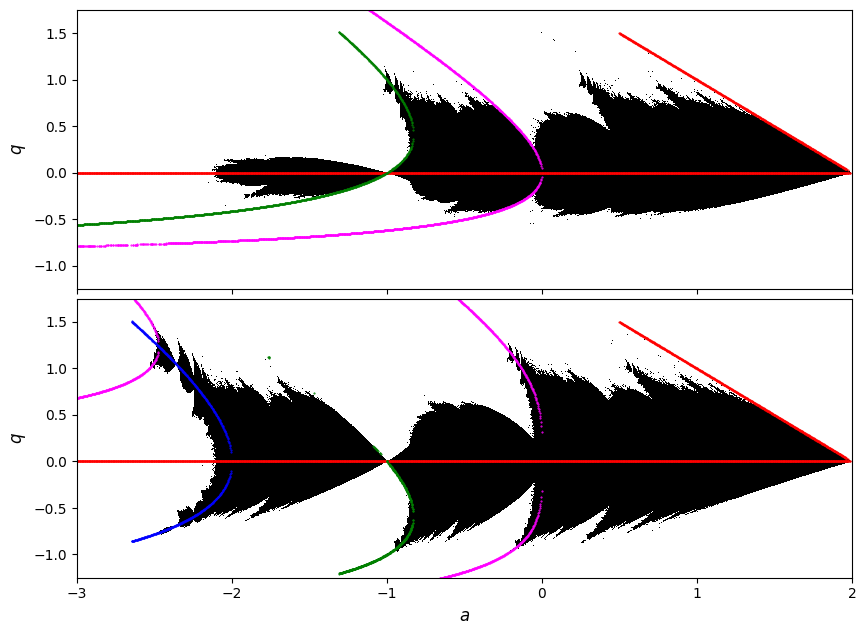

In [53]:
fig, (ax, ay) = plt.subplots( nrows=2, figsize=(10, 10), sharex=True, gridspec_kw={'hspace': -0.4}, num=1, clear=True)

ax.imshow(fractal_a.T, aspect=3/5, origin='lower', interpolation='nearest', cmap='gray', extent=(-3, 2, -1.25, 1.75))
for data in box_a_01:
    ax.scatter(*data.T, color='red', s=0.25)
for data in box_a_02:
    ax.scatter(*data.T, color='blue', s=0.25)
for data in box_a_03:
    ax.scatter(*data.T, color='green', s=0.25)
for data in box_a_04:
    ax.scatter(*data.T, color='magenta', s=0.25)

ay.imshow(fractal_b.T, aspect=3/5, origin='lower', interpolation='nearest', cmap='gray', extent=(-3, 2, -1.25, 1.75))
for data in box_b_01:
    ay.scatter(*data.T, color='red', s=0.25)
for data in box_b_02:
    ay.scatter(*data.T, color='blue', s=0.25)
for data in box_b_03:
    ay.scatter(*data.T, color='green', s=0.25)
for data in box_b_04:
    ay.scatter(*data.T, color='magenta', s=0.25)

ax.set_ylabel(r'$q$', fontsize=12)
ay.set_ylabel(r'$q$', fontsize=12)  
ay.set_xlabel(r'$a$', fontsize=12)

ax.set_ylim(-1.25, 1.75)
ay.set_ylim(-1.25, 1.75)

plt.show()

# 2D BBM fixed points

In this example fixed points of beam-beam mapping are evaluated for the following two cases:
 - fixed $\nu$ and $\xi$ values
 - fixed $\xi$ value and scan over $\nu$ with initials on symmetry lines (simialr to the Henon case)

$$
\begin{align*}
& q = p \\
& p = -q + 2 \cos(2 \pi \nu) p - \frac{8 \pi \xi}{p} \sin(2 \pi \nu) \left(1 - e^{-\frac{p^2}{2}} \right)
\end{align*}
$$

Import:

In [54]:
from typing import Callable

import numpy as np
from numpy.typing import NDArray

from numba import njit
from numba import prange

from domain.mappings import bb_map_forward as mapping
from domain.mappings import bb_map_inverse as inverse
from domain.mappings import bb_map_diagonal_symmetry as line_a
from domain.mappings import bb_map_force_symmetry as line_b

from domain.fp import trajectory
from domain.fp import expand
from domain.fp import problem
from domain.fp import exact
from domain.fp import unique

from domain.cbm import edges
from domain.cbm import tiles
from domain.cbm import psolve

from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib import colormaps

Since BBM is stable, there is no escape of initials, to show internal structures REM chaos indicator is used.
Define and compute REM for BBM:

In [55]:
@njit(parallel=True)
def rem(
    limit: int,
    ks: NDArray[np.float64],
    qs: NDArray[np.float64],
    forward: Callable[[NDArray[np.float64], np.float64], NDArray[np.float64]],
    inverse: Callable[[NDArray[np.float64], np.float64], NDArray[np.float64]],
    line: Callable[[NDArray[np.float64], np.float64], NDArray[np.float64]]
) -> NDArray[np.float64]:
    ps = np.empty(len(qs), dtype=np.float64)
    rs = np.empty((len(ks), len(qs)), dtype=np.float64)
    for i in prange(len(ks)):
        ps = line(qs, ks[i])
        xi = np.stack((qs, ps))
        xs = np.copy(xi)
        for _ in range(limit):
            xs = forward(xs, ks[i])
        xs = xs + 1.0E-16
        for _ in range(limit):
            xs = inverse(xs, ks[i])        
        dq, dp = xs - xi
        rs[i] = np.sqrt(dq*dq + dp*dp)
    return rs

In [56]:
n = 2**10
m = 2001

a = np.linspace(0.0, 1.0, m)
b = np.full_like(a, 0.25)
c = np.full_like(a, 0.0)
ks = np.ascontiguousarray(np.stack([a, b, c]).T)
qs = np.linspace(-25.0, 25.00, m) + 1.0E-16

rem_a = np.log10(1.0E-16 + rem(n, ks, qs, mapping, inverse, line_a))
rem_b = np.log10(1.0E-16 + rem(n, ks, qs, mapping, inverse, line_b))

Define expanded fixed point problem:

In [57]:
residual = problem(expand(mapping))

Set region boundaries, edge indices and tiles:

In [58]:
bs = np.array([[-25.0, 25.0], [-25.0, 25.0]])
es = edges(len(bs))
ns = np.array([128, 128])
ts = tiles(bs, ns, overlap=0.1)
ts.shape

(16384, 2, 2)

In [59]:
nu = np.float64(0.62)
xi = np.float64(0.25)
ks = np.float64(0.00)
knobs = np.stack([nu, xi, ks])

Compute fixed point and plot phase space trajectories:

In [60]:
order = 3

parameters = np.stack([nu, xi, ks, order])
checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-9, ncube=64, nball=512, max_iterations=512)
points = points[np.bool_(checks) * (counts != 512)]
points = points[exact(order, mapping, points, knobs, tolerance=1.0E-6)]
if points.size != 0:
    points03 = points[unique(order, mapping, points, knobs, tolerance=1.0E-6)]
    chains03 = trajectory(order, mapping, points.T, knobs).swapaxes(0, 1)
points03

array([[-3.90510218,  2.29625853],
       [-3.05003771,  3.05003771],
       [-2.29625853,  3.90510218]])

In [61]:
order = 8

parameters = np.stack([nu, xi, ks, order])
checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-9, ncube=64, nball=512, max_iterations=512)
points = points[np.bool_(checks) * (counts != 512)]
points = points[exact(order, mapping, points, knobs, tolerance=1.0E-6)]
if points.size != 0:
    points08 = points[unique(order, mapping, points, knobs, tolerance=1.0E-6)]
    chains08 = trajectory(order, mapping, points.T, knobs).swapaxes(0, 1)
points08

array([[-1.27880049e+01,  5.51976238e+00],
       [-8.62532518e+00, -5.98912115e-10]])

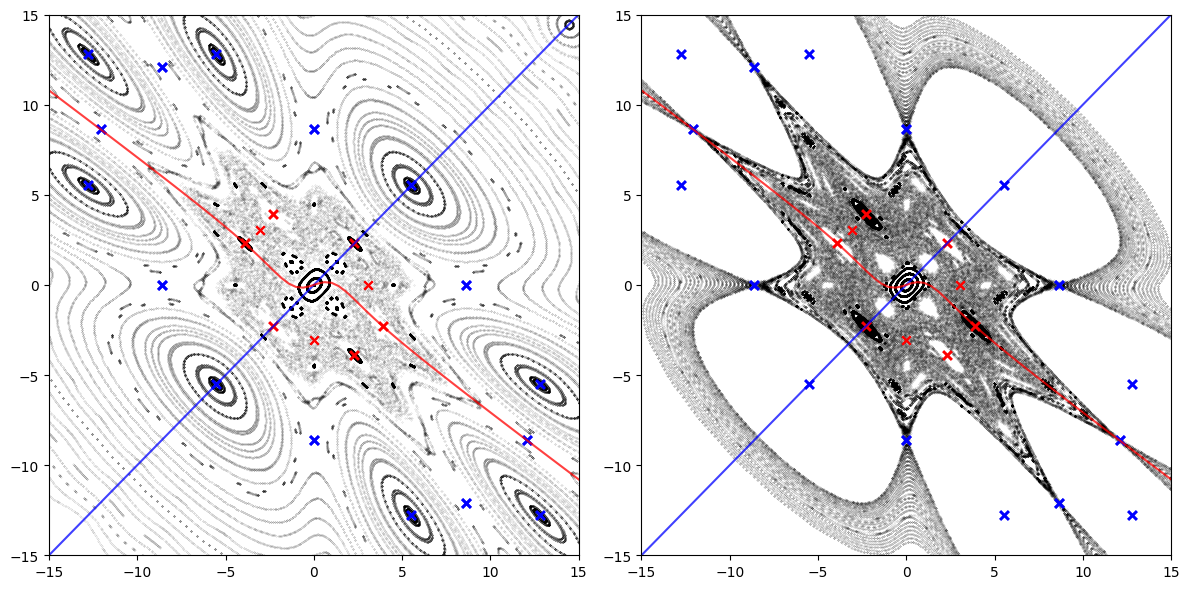

In [62]:
# Plot

length = 2**12

parameters = np.stack([nu, xi, ks])

qs = np.linspace(0.0, 20.0, 64)
ps = line_a(qs, knobs)
xs = np.stack([qs, ps])
td = trajectory(length, mapping, xs, knobs)

qs = np.linspace(0.0, 20.0, 64)
ps = line_b(qs, knobs)
xs = np.stack([qs, ps])
tf = trajectory(length, mapping, xs, knobs)

qs_d = np.linspace(-20.0, 20.0, 100)
ps_d = line_a(qs_d, knobs)

qs_f = np.linspace(-20.0, 20.0, 100)
ps_f = line_b(qs_f, knobs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6)) 

ax1.plot(qs_d, ps_d, color='blue', alpha=0.75)
ax1.plot(qs_f, ps_f, color='red', alpha=0.75)
ax1.scatter(*td.swapaxes(0, 1), color='black', s=0.05, alpha=0.25)
ax1.scatter(*chains03, color='red', marker='x')
ax1.scatter(*chains08, color='blue', marker='x')
ax1.set_xlim(-15, 15)
ax1.set_ylim(-15, 15)

ax2.plot(qs_d, ps_d, color='blue', alpha=0.75)
ax2.plot(qs_f, ps_f, color='red', alpha=0.75)
ax2.scatter(*tf.swapaxes(0, 1), color='black', s=0.05, alpha=0.25)
ax2.scatter(*chains03, color='red', marker='x')
ax2.scatter(*chains08, color='blue', marker='x')
ax2.set_xlim(-15, 15)
ax2.set_ylim(-15, 15)

plt.tight_layout()
plt.show()

Set parameter scan range:

In [63]:
m = 2001
nus = np.linspace(0.0, 1.0, m)

Compute fixed point for each parameter value:

In [64]:
order = 1

box_a_01 = []
box_b_01 = []

for nu in tqdm(nus):
    knobs = np.stack([nu, xi, ks])
    parameters = np.stack([*knobs, order])
    checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-9, ncube=32, nball=512, max_iterations=512, max_expansions=64)
    points = points[(checks == 1) & (counts != 512)]
    points = points[exact(order, mapping, points, knobs, tolerance=1.0E-6)]
    if points.size == 0:
        continue
    points = points[unique(order, mapping, points, knobs, tolerance=1.0E-6)]           
    points = trajectory(order, mapping, np.ascontiguousarray(points.T), knobs).T.reshape(-1, 2)
    qs, ps = points.T
    ma = np.abs(ps - line_a(qs, knobs)) < 1.0E-6
    mb = np.abs(ps - line_b(qs, knobs)) < 1.0E-6
    vs = np.stack([np.full_like(qs, nu), qs]).T
    box_a_01.append(vs[ma])
    box_b_01.append(vs[mb])    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2001/2001 [01:25<00:00, 23.33it/s]


In [65]:
order = 2

box_a_02 = []
box_b_02 = []

for nu in tqdm(nus):
    knobs = np.stack([nu, xi, ks])
    parameters = np.stack([*knobs, order])
    checks, points, counts = psolve(es, ts, residual, parameters, tolerance=1.0E-9, ncube=32, nball=512, max_iterations=512, max_expansions=64)
    points = points[(checks == 1) & (counts != 512)]
    points = points[exact(order, mapping, points, knobs, tolerance=1.0E-6)]
    if points.size == 0:
        continue
    points = points[unique(order, mapping, points, knobs, tolerance=1.0E-6)]           
    points = trajectory(order, mapping, np.ascontiguousarray(points.T), knobs).T.reshape(-1, 2)
    qs, ps = points.T
    ma = np.abs(ps - line_a(qs, knobs)) < 1.0E-6
    mb = np.abs(ps - line_b(qs, knobs)) < 1.0E-6
    vs = np.stack([np.full_like(qs, nu), qs]).T
    box_a_02.append(vs[ma])
    box_b_02.append(vs[mb])    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2001/2001 [01:50<00:00, 18.06it/s]


Plot combined results:

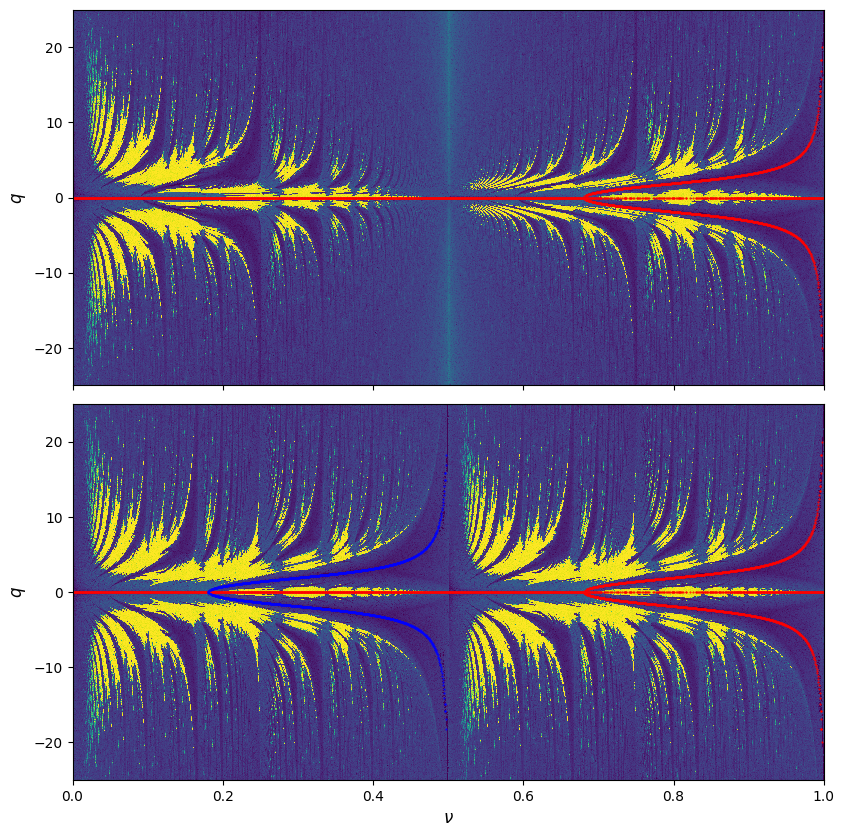

In [66]:
cmap = colormaps.get_cmap('viridis')
cmap.set_bad(color='lightgray')

fig, (ax, ay) = plt.subplots(nrows=2, figsize=(10, 10), sharex=True, gridspec_kw={'hspace': 0.05}, num=1, clear=True)

ax.imshow(rem_a.T, aspect=1/100, vmin=-15.0, vmax=1.0, origin='lower', cmap=cmap, interpolation='nearest', extent=(0, 1, -25, 25))
data = np.concatenate([value.squeeze().reshape(-1, 2)for value in box_a_01])
ax.scatter(*data.T, color='red', s=0.25)
data = np.concatenate([value.squeeze().reshape(-1, 2)for value in box_a_02])
ax.scatter(*data.T, color='blue', s=0.25)
ax.set_xlim(0., 1.)
ax.set_ylim(-25, 25)

ay.imshow(rem_b.T, aspect=1/100, vmin=-15.0, vmax=1.0, origin='lower', cmap=cmap, interpolation='nearest', extent=(0, 1, -25, 25))
data = np.concatenate([value.squeeze().reshape(-1, 2)for value in box_b_01])
ay.scatter(*data.T, color='red', s=0.25)
data = np.concatenate([value.squeeze().reshape(-1, 2)for value in box_b_02])
ay.scatter(*data.T, color='blue', s=0.25)
ay.set_xlim(0, 1.)
ay.set_ylim(-25, 25)

ax.set_ylabel(r'$q$', fontsize=12)
ay.set_ylabel(r'$q$', fontsize=12)  
ay.set_xlabel(r'$\nu$', fontsize=12)

plt.show()

# 2D Henon mapping invariant hyperbolic manifolds

In [1]:
from tqdm import tqdm

from numpy import float64
from numpy.typing import NDArray
import numpy as np

from domain.fp import chain
from domain.fp import combine
from domain.fp import identify
from domain.fp import monodromy
from domain.fp import search
from domain.fp import trajectory

from domain.manifold import construct
from domain.mappings import forward2D
from domain.mappings import inverse2D

from domain.domain import Domain

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True

In [2]:
# Set mapping parameters

a, b = 0.4678, 0.0
parameters = np.asarray([a, b])
state = np.array([0.05, -0.01])

In [3]:
# Test

state = np.array([0.05, -0.01]).reshape(-1, 1)

print(state)
print(inverse2D(forward2D(state, parameters), parameters))
print()

[[ 0.05]
 [-0.01]]
[[ 0.05]
 [-0.01]]



In [4]:
# Set bounds

bounds = np.array([[-2.0, 2.0], [-2.0, 2.0]])
pieces = np.array([64, 64])

In [5]:
# Perform fixed point search and along with stability type check

limit = 8
fps = []
for order in tqdm(range(1, limit + 1)):
    points = search(
        order, 
        forward2D, 
        bounds, 
        pieces, 
        parameters, 
        tolerance=1.0E-9, 
        filtering=1.0E-9, 
        duplicate=1.0E-6,
        ncube=16,
        nball=128,
        max_iterations=256,
        max_expansions=64
    )
    for index, point in enumerate(points):
        values, vectors = np.linalg.eig(monodromy(order, forward2D)(point, parameters))
        values, _ = combine(values, vectors)
        kind = identify(values)
        fps.append((order, kind, chain(order, forward2D)(point.reshape(-1, 1), parameters)))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [01:53<00:00, 14.22s/it]


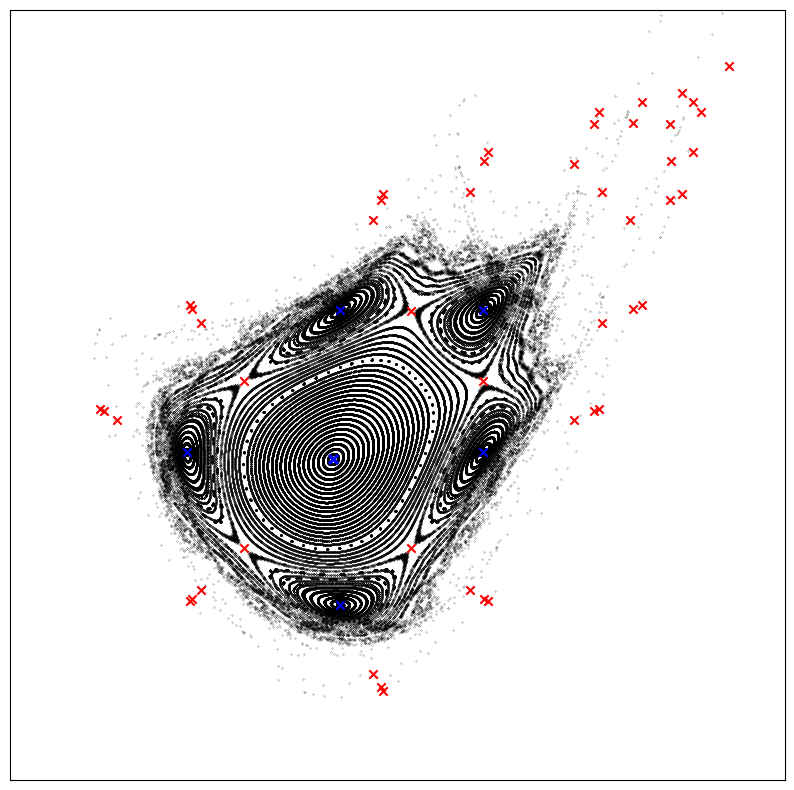

In [6]:
# Plot phase space trajectories and fixed points

qs = np.linspace(0.0, 1.0, 64)
ps = np.linspace(0.0, 1.0, 64)
xs = np.stack([qs, ps])

table = trajectory(2**12, forward2D, xs, parameters)

plt.figure(figsize=(10, 10))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1, marker='.')
for order, kind, points in fps:
    plt.scatter(*np.squeeze(points.T), marker='x', color='blue' if kind=='E' else 'red')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-1.25, 1.75)
plt.ylim(-1.25, 1.75)
plt.show()

In [7]:
# Filter fixed points (keep only one of each hyperbolic 

hps = []
for order, kind, points in fps:
    if 'H' in kind:
        point, *_ = points
        hps.append((order, kind, point.flatten()))

In [8]:
# Generate hyperbolic manifolds
# Note, both stable and unstable parts are generated
# Only escaping initials are keps (escaped after cut number of iterations)

data = []
for order, _, point in hps:
    sc, uc = construct(
        [order],
        np.asarray([point]),
        forward2D,
        inverse2D,
        parameters,
        generate=False,
        stable=True,
        unstable=True,
        scale=1.0E-3,
        nline=512,
        cut=8192,
        count=8192 + 1,
        full=False,
        radius=1.0E+3,
        strict=False,
        reduce=False,
        size=1.0E-3,
        total=1E+6
    )
    data.append([order, (sc, uc)])

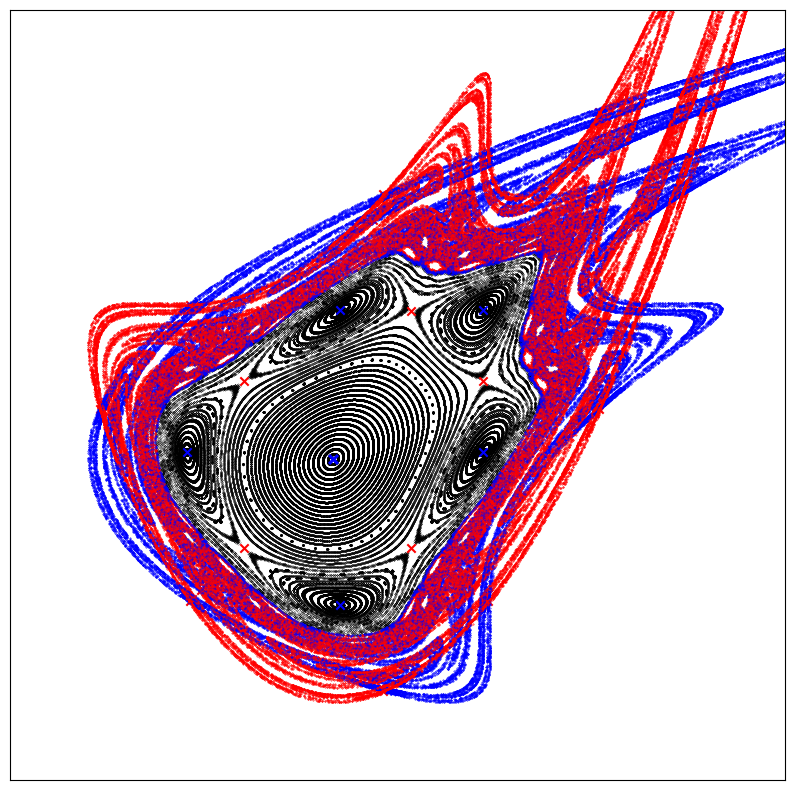

In [9]:
# Plot phase space trajectories and fixed points

qs = np.linspace(0.0, 1.0, 64)
ps = np.linspace(0.0, 1.0, 64)
xs = np.stack([qs, ps])

table = trajectory(2**12, forward2D, xs, parameters)

plt.figure(figsize=(10, 10))
plt.scatter(*table.swapaxes(0, 1), color='black', s=0.1, marker='.')
for order, kind, points in fps:
    plt.scatter(*np.squeeze(points.T), marker='x', color='blue' if kind=='E' else 'red')
for _, (sc, uc) in data:
    plt.scatter(*sc.T, color='blue', s=0.5, marker='.')
    plt.scatter(*uc.T, color='red', s=0.5, marker='.')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-1.25, 1.75)
plt.ylim(-1.25, 1.75)
plt.show()

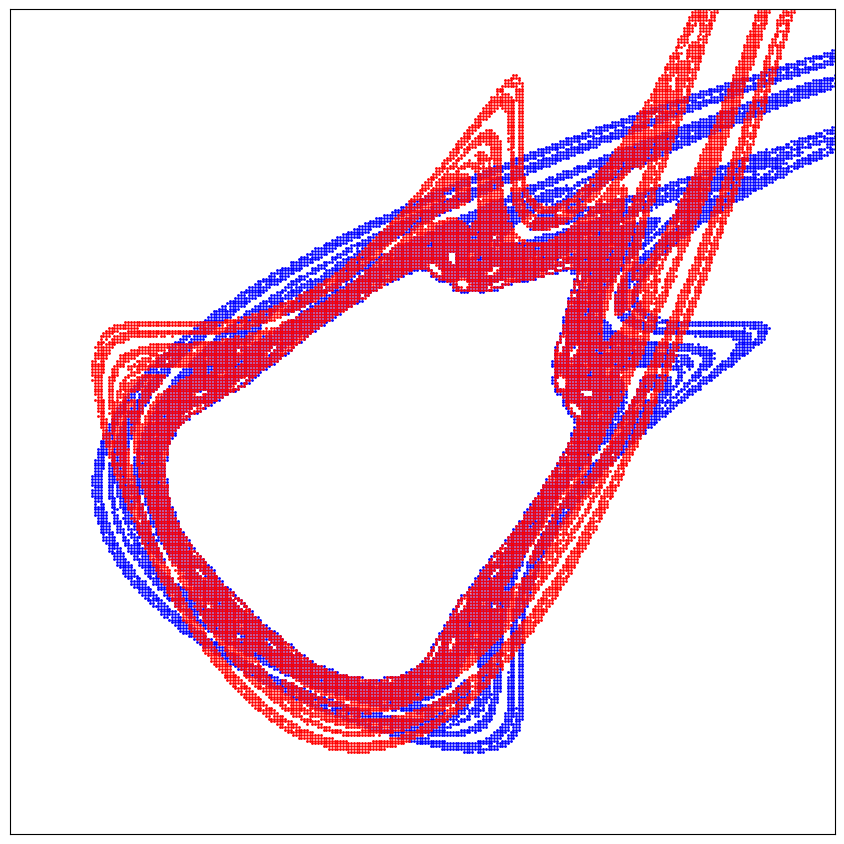

In [10]:
# Define domain and project on it

dimension = 2
dl = 0.01
dr = dl*dimension**0.5
lb = np.array([-2, -2])
ub = np.array([+2, +2])

domain_inverse = Domain(lb, ub, dl)
domain_forward = Domain(lb, ub, dl)
for _, (sc, uc) in data:
    domain_inverse.update(sc)
    domain_forward.update(uc)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

width, height = ub - lb
fig, ax = plt.subplots(figsize=(10.0, 10.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
plt.errorbar(*domain_inverse.construct.T, fmt=' ', ms=1, marker='o', color='blue', alpha=1, zorder=0)
plt.errorbar(*domain_forward.construct.T, fmt=' ', ms=1, marker='o', color='red', alpha=1, zorder=0)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(-1.25, 1.75)
plt.ylim(-1.25, 1.75)
plt.show()

# 4D Henon mapping invariant hyperbolic manifolds

In [1]:
from tqdm import tqdm

import numpy as np

from domain.fp import chain
from domain.fp import combine
from domain.fp import identify
from domain.fp import monodromy
from domain.fp import search

from domain.manifold import construct
from domain.mappings import forward4D
from domain.mappings import inverse4D

from domain.adapters import scalarize
from domain.scan import iterate
from domain.scan import count
from domain.scan import scan
from domain.volume import directions
from domain.da import da
from domain.da import refine
from domain.domain import Domain

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
mpl.rcParams['text.usetex'] = True

In [2]:
# Set mapping parameters

nux, nuy = 0.280, 0.310
mux, muy = 2.0*np.pi*nux, 2.0*np.pi*nuy
cx, sx = np.cos(mux), np.sin(mux)
cy, sy = np.cos(muy), np.sin(muy)
mu = 1.0
parameters = np.asarray([cx, sx, cy, sy, mu])

In [3]:
# Test

state = np.array([0.05, -0.05, 0.01, 0.01]).reshape(-1, 1)

print(state)
print(inverse4D(forward4D(state, parameters), parameters))
print()

[[ 0.05]
 [-0.05]
 [ 0.01]
 [ 0.01]]
[[ 0.05]
 [-0.05]
 [ 0.01]
 [ 0.01]]



In [4]:
# Set bounds

bounds = np.repeat(np.array([[-1.5, 1.5]]), 4, axis=0)
pieces = np.full(4, 16)

In [5]:
# Perform fixed point search and along with stability type check

limit = 16
fps = []
for order in tqdm(range(1, limit + 1)):
    points = search(
        order,
        forward4D,
        bounds,
        pieces,
        parameters,
        tolerance=1.0E-12,
        filtering=1.0E-9,
        duplicate=1.0E-6,
        ncube=16,
        nball=2**10,
        max_iterations=256,
        max_expansions=64
    )
    for index, point in enumerate(points):
        values, vectors = np.linalg.eig(monodromy(order, forward4D)(point, parameters))
        values, _ = combine(values, vectors)
        kind = identify(values)
        fps.append((order, kind, chain(order, forward4D)(point.reshape(-1, 1), parameters)))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [39:09<00:00, 146.83s/it]


In [6]:
# Filter fixed points (keep only one representative of each hyperbolic chain)

hps = []
for order, kind, points in fps:
    if 'H' in kind:
        point, *_ = points
        hps.append((order, kind, point.flatten()))

In [7]:
# Generate hyperbolic manifolds
# Both stable and unstable parts are generated separately
# Only initials escaping by count are retained when full is False

data = []
for order, _, point in tqdm(hps):
    sc, uc = construct(
        [order],
        np.asarray([point]),
        forward4D,
        inverse4D,
        parameters,
        generate=False,
        stable=True,
        unstable=True,
        scale=0.01,
        nline=4096,
        nball=8192,
        cut=8192,
        count=8192 + 1,
        full=False,
        radius=1.0E+3,
        strict=False,
        reduce=False,
        size=1.0E-3,
        total=1E+6,
        surface=False
    )
    data.append([order, (sc, uc)])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:54<00:00, 11.50s/it]


In [8]:
# Define domain and project manifolds on it

dimension = 4
dl = 0.01
dr = dl*dimension**0.5
lb = np.array([-1.5, -1.5, -1.5, -1.5])
ub = np.array([+1.5, +1.5, +1.5, +1.5])

domain_inverse = Domain(lb, ub, dl)
domain_forward = Domain(lb, ub, dl)
for _, (sc, uc) in data:
    domain_inverse.update(sc)
    domain_forward.update(uc)

domain = Domain(lb, ub, dl)
domain.update(domain_forward.construct)
domain.update(domain_inverse.construct)

print(domain_forward.size)
print(domain_inverse.size)
print(domain.size)

1942875
1961761
2499994


In [10]:
# Define forward and inverse domain plane masks (projected)

epsilon = 1.0E-6
width = 1

Qx_forward, Qy_forward, Px_forward, Py_forward = domain_forward.construct.T
mqx_forward = np.abs(Qx_forward) < width*dl + epsilon
mqy_forward = np.abs(Qy_forward) < width*dl + epsilon
mpx_forward = np.abs(Px_forward) < width*dl + epsilon
mpy_forward = np.abs(Py_forward) < width*dl + epsilon

Qx_inverse, Qy_inverse, Px_inverse, Py_inverse = domain_inverse.construct.T
mqx_inverse = np.abs(Qx_inverse) < width*dl + epsilon
mqy_inverse = np.abs(Qy_inverse) < width*dl + epsilon
mpx_inverse = np.abs(Px_inverse) < width*dl + epsilon
mpy_inverse = np.abs(Py_inverse) < width*dl + epsilon

In [11]:
# Survival count

size = 8192
threshold = 1.0E+3
center = np.array([0.0, 0.0, 0.0, 0.0])

objective = iterate(size, threshold, scalarize(forward4D))
count_forward = count(size, threshold, scalarize(forward4D))
count_inverse = count(size, threshold, scalarize(inverse4D))

In [12]:
# qx-qy

In [13]:
n = 1000
qx = np.linspace(-1.5, 1.5, n)
qy = np.linspace(-1.5, 1.5, n)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxqy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy, count_forward, parameters)

mask_qxqy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy_inverse, count_inverse, parameters)

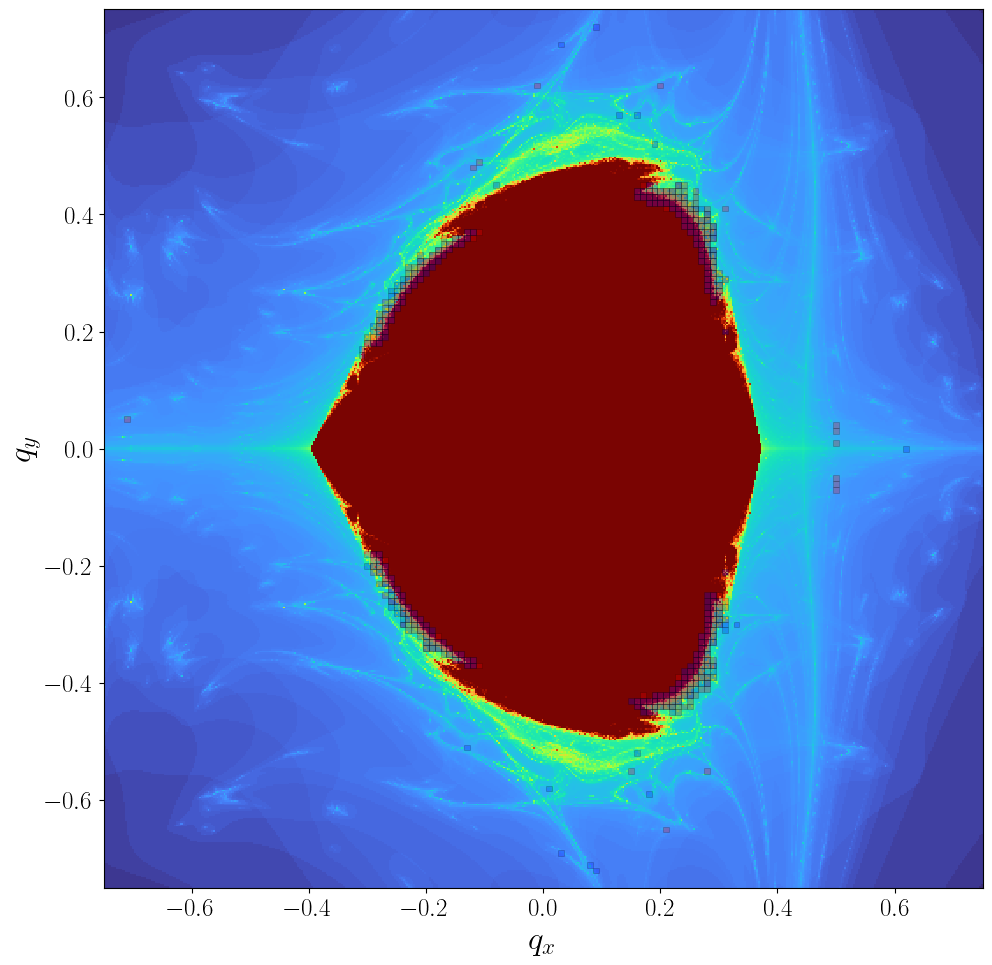

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qxqy + mask_qxqy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_forward[mpx_forward*mpy_forward], Qy_forward[mpx_forward*mpy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_inverse[mpx_inverse*mpy_inverse], Qy_inverse[mpx_inverse*mpy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
plt.xlabel('qx')
plt.ylabel('qy')
plt.xlim(-0.75, 0.75)
plt.ylim(-0.75, 0.75)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$q_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [15]:
# qx-px

In [16]:
n = 1000
qx = np.linspace(-1.5, 1.5, n)
px = np.linspace(-1.5, 1.5, n)
qxpx = np.stack(np.meshgrid(qx, px, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qypy = np.full_like(qxpx, 0.0)
qx, px = qxpx.T
qy, py = qypy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxpx = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxpx, count_forward, parameters)

mask_qxpx_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxpx_inverse, count_inverse, parameters)

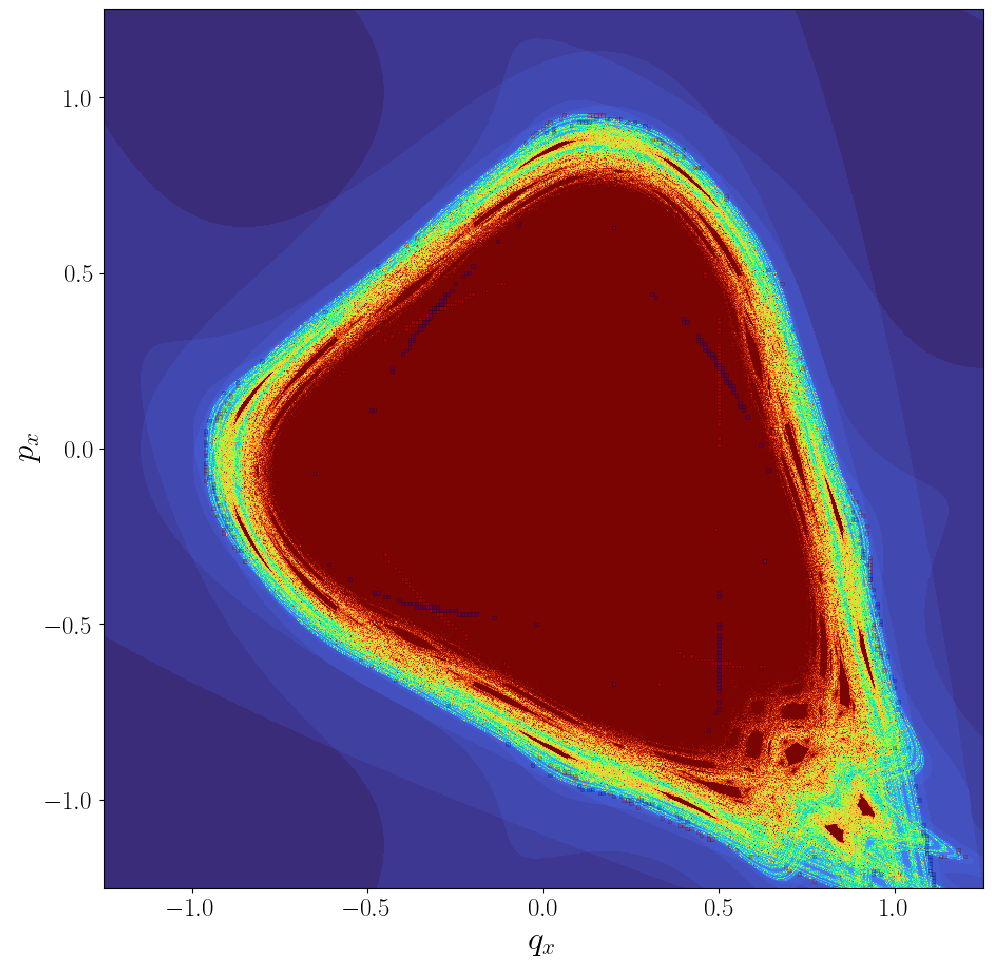

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qxpx + mask_qxpx_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_forward[mqy_forward*mpy_forward], Px_forward[mqy_forward*mpy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qx_inverse[mqy_inverse*mpy_inverse], Px_inverse[mqy_inverse*mpy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$p_x$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [18]:
# qy-py

In [19]:
n = 1000
qy = np.linspace(-1.5, 1.5, n)
py = np.linspace(-1.5, 1.5, n)
qypy = np.stack(np.meshgrid(qy, py, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qxpx = np.full_like(qypy, 0.0)
qy, py = qypy.T
qx, px = qxpx.T
xs = np.stack([qx, qy, px, py]).T

mask_qypy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qypy, count_forward, parameters)

mask_qypy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qypy_inverse, count_inverse, parameters)

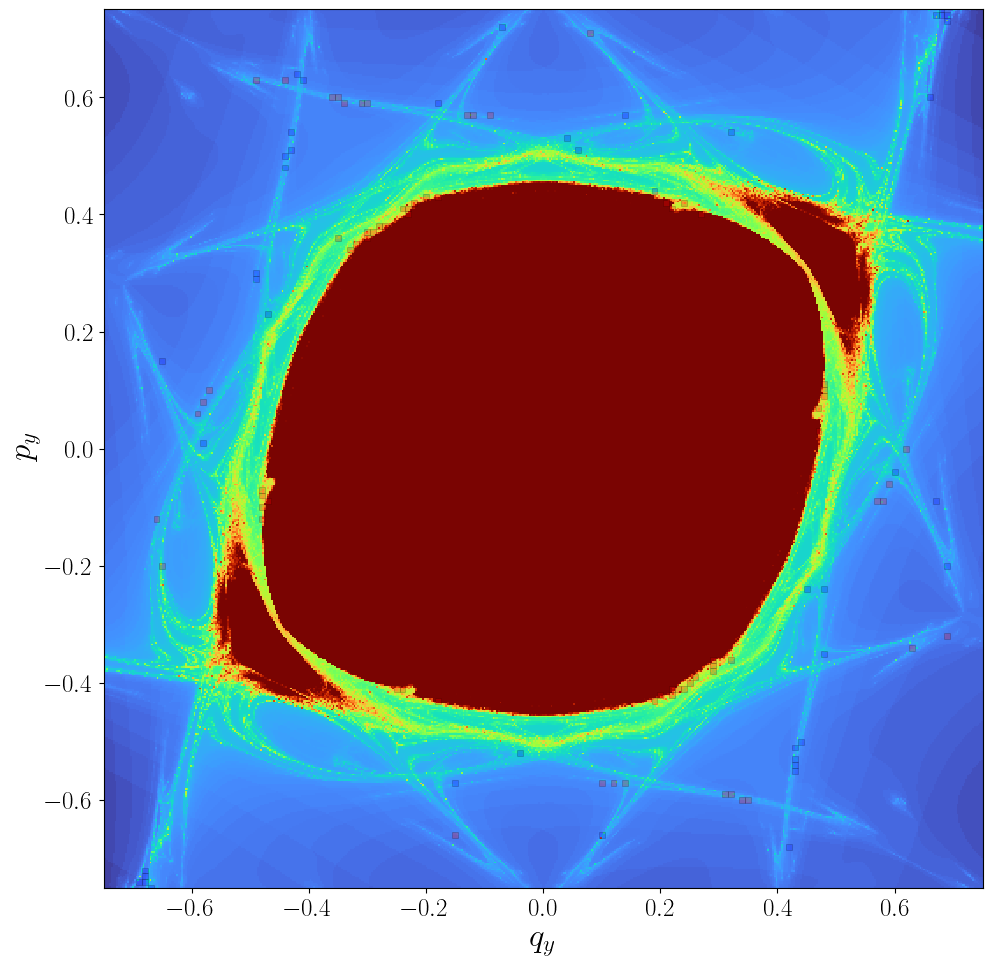

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qypy + mask_qypy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qy_forward[mqx_forward*mpx_forward], Py_forward[mqx_forward*mpx_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Qy_inverse[mqx_inverse*mpx_inverse], Py_inverse[mqx_inverse*mpx_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
plt.xlim(-0.75, 0.75)
plt.ylim(-0.75, 0.75)
plt.xlabel(r"$q_y$", fontsize=24)
plt.ylabel(r"$p_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [21]:
# px-py

In [22]:
n = 1000
px = np.linspace(-1.5, 1.5, n)
py = np.linspace(-1.5, 1.5, n)
pxpy = np.stack(np.meshgrid(px, py, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qxqy = np.full_like(pxpy, 0.0)
px, py = pxpy.T
qx, qy = qxqy.T
xs = np.stack([qx, qy, px, py]).T

mask_pxpy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_pxpy, count_forward, parameters)

mask_pxpy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_pxpy_inverse, count_inverse, parameters)

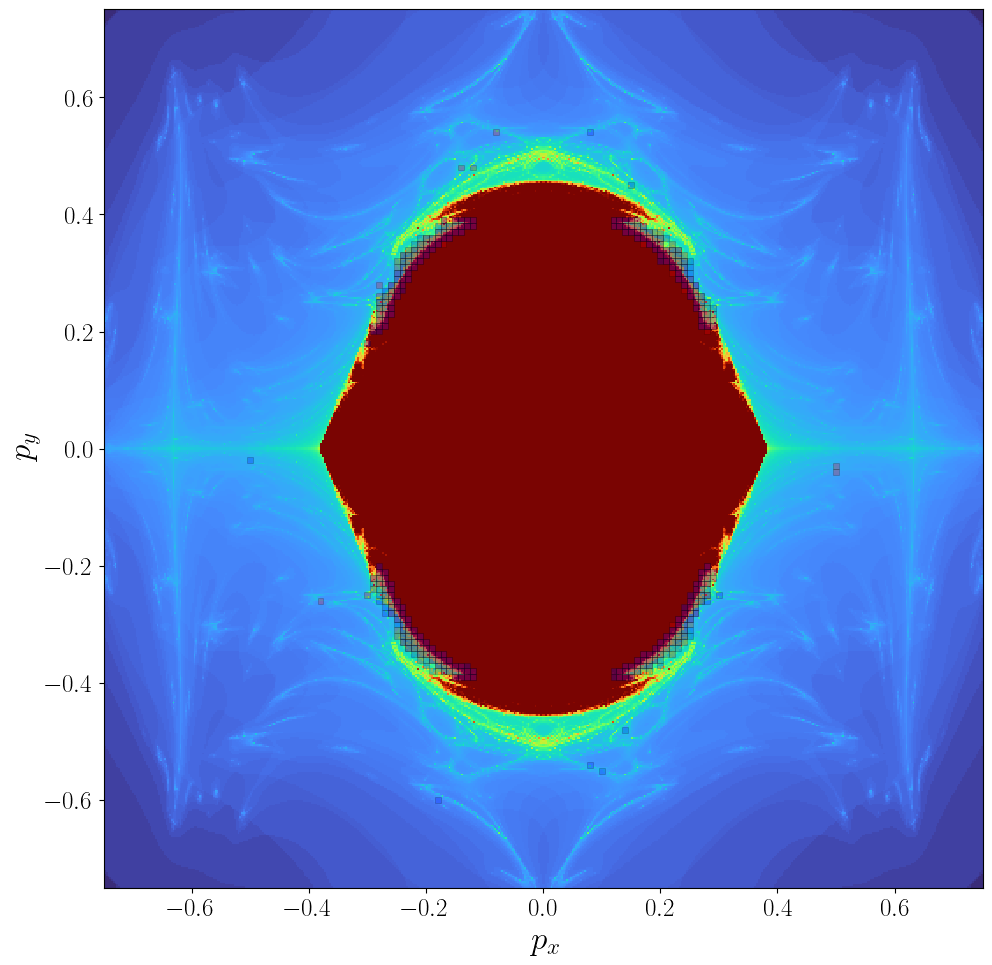

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_pxpy + mask_pxpy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Px_forward[mqx_forward*mqy_forward], Py_forward[mqx_forward*mqy_forward]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
local = Domain([-1.5, -1.5], [+1.5, +1.5], dl)
local.update(np.stack([Px_inverse[mqx_inverse*mqy_inverse], Py_inverse[mqx_inverse*mqy_inverse]]).T)
for cx, cy in local.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
plt.xlim(-0.75, 0.75)
plt.ylim(-0.75, 0.75)
plt.xlabel(r"$p_x$", fontsize=24)
plt.ylabel(r"$p_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()